##### The objective of this project is to perform exploratory data analysis (EDA) on a structured student dataset using Python. The task involves data preprocessing, transformation, and visualization to analyze distributions, relationships, and patterns among numerical and categorical features.

The implementation must include:

* Data loading and cleaning using Pandas
* Numerical operations and aggregations using NumPy
* Univariate and multivariate analysis using Matplotlib and Seaborn
* Creation of subplots to visualize multiple features in a single figure
* Generation of correlation matrices and heatmaps
* Application of groupby operations for aggregated insights
* Visualization of data distributions, categorical comparisons, and feature relationships

In [1]:
# Import Required Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
# Load Dataset
df = pd.read_csv("B:/SELF_LEARNING/data/student.csv")
df.head()

,Name,Age,Gender,Department,StudyHours,Attendance,Marks
0,Amit,23,Male,IT,5.0,85.0,78.0
1,Sara,21,Female,HR,6.0,88.0,85.0
2,John,25,Male,Finance,NaN,75.0,70.0
3,Priya,22,Female,IT,7.0,92.0,88.0
4,Rahul,24,Male,HR,3.0,NaN,65.0


In [28]:
# Dataset Cleaning
print(df.isnull().sum())  # Missing Values

# Handling Missing Values
df["StudyHours"]=df["StudyHours"].fillna(df["StudyHours"].mean())
df["Attendance"]=df["Attendance"].fillna(df["Attendance"].median())
df["Marks"]=df["Marks"].fillna(df["Marks"].mean())
df["Department"]=df["Department"].fillna(df["Department"].mode()[0])

# Detect Outliers
df.describe()    # age cannot be 120(outlier)

df = df[df['Age']<100]  # remove Outlier


Name          0
Age           0
Gender        0
Department    0
StudyHours    0
Attendance    0
Marks         0
dtype: int64


In [31]:
## Verifying Clean Data

print(df.isnull().sum())

df.describe()

Name          0
Age           0
Gender        0
Department    0
StudyHours    0
Attendance    0
Marks         0
dtype: int64


,Age,StudyHours,Attendance,Marks
count,11.000000,11.000000,11.000000,11.000000
mean,22.909091,5.785124,84.636364,79.636364
std,1.578261,2.040204,10.259364,12.101841
min,21.000000,2.000000,60.000000,55.000000
25%,22.000000,5.000000,82.500000,74.000000
50%,23.000000,6.000000,85.000000,81.000000
75%,23.500000,7.000000,91.000000,88.500000
max,26.000000,9.000000,96.000000,94.000000


In [ ]:
df.info()
print(df.head())
df.describe()

<class 'pandas.DataFrame'>
Index: 11 entries, 0 to 11
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        11 non-null     str    
 1   Age         11 non-null     int64  
 2   Gender      11 non-null     str    
 3   Department  11 non-null     str    
 4   StudyHours  11 non-null     float64
 5   Attendance  11 non-null     float64
 6   Marks       11 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 854.0 bytes
    Name  Age  Gender Department  StudyHours  Attendance  Marks
0   Amit   23    Male         IT    5.000000        85.0   78.0
1   Sara   21  Female         HR    6.000000        88.0   85.0
2   John   25    Male    Finance    5.636364        75.0   70.0
3  Priya   22  Female         IT    7.000000        92.0   88.0
4  Rahul   24    Male         HR    3.000000        85.0   65.0


,Age,StudyHours,Attendance,Marks
count,11.000000,11.000000,11.000000,11.000000
mean,22.909091,5.785124,84.636364,79.636364
std,1.578261,2.040204,10.259364,12.101841
min,21.000000,2.000000,60.000000,55.000000
25%,22.000000,5.000000,82.500000,74.000000
50%,23.000000,6.000000,85.000000,81.000000
75%,23.500000,7.000000,91.000000,88.500000
max,26.000000,9.000000,96.000000,94.000000


In [37]:
df

,Name,Age,Gender,Department,StudyHours,Attendance,Marks
0,Amit,23,Male,IT,5.000000,85.0,78.0
1,Sara,21,Female,HR,6.000000,88.0,85.0
2,John,25,Male,Finance,5.636364,75.0,70.0
3,Priya,22,Female,IT,7.000000,92.0,88.0
4,Rahul,24,Male,HR,3.000000,85.0,65.0
5,Neha,23,Female,Finance,8.000000,95.0,92.0
6,David,26,Male,IT,2.000000,60.0,55.0
7,Ankit,22,Male,HR,5.000000,80.0,79.0
8,Pooja,21,Female,Finance,6.000000,85.0,81.0
9,Riya,23,Female,IT,7.000000,90.0,89.0


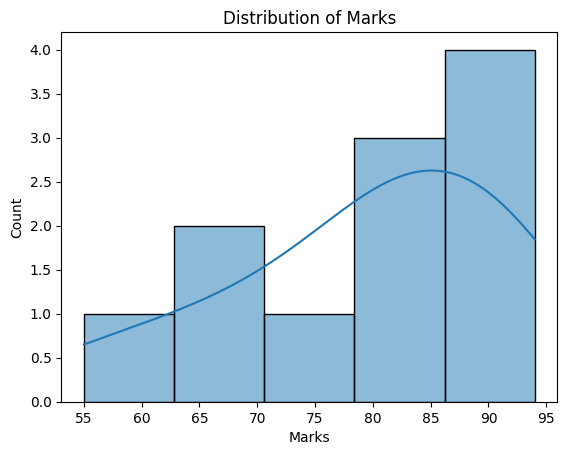

In [36]:
# EDA START
# Distribution Analysis

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Marks"],kde=True)
plt.title("Distribution of Marks")
plt.show()

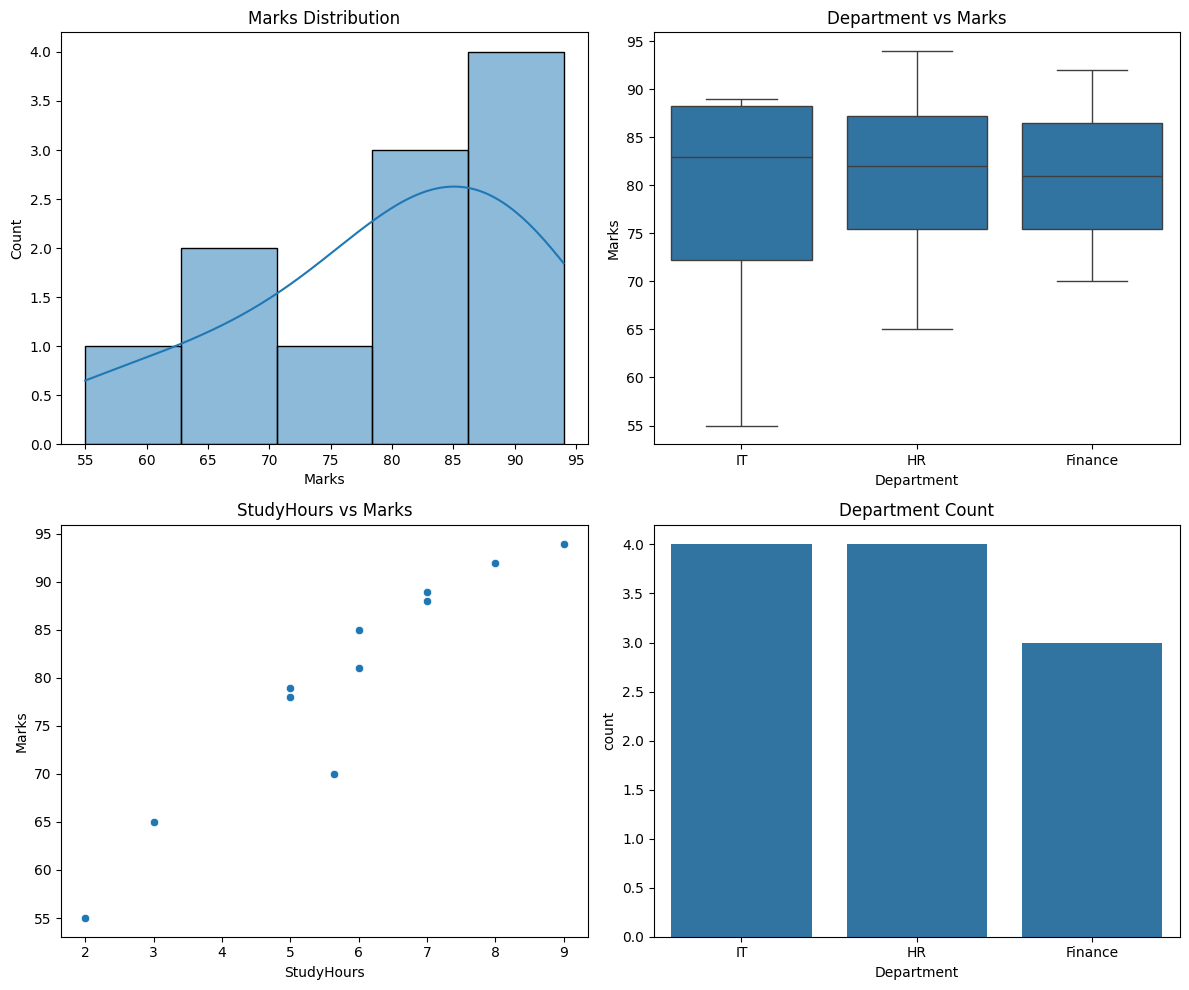

In [40]:
# Subplot Dashboard

fig,axes = plt.subplots(2, 2, figsize=(12,10))

# Histogram Plot
sns.histplot(df["Marks"],kde=True,ax=axes[0,0])
axes[0,0].set_title("Marks Distribution")

# Box Plot
sns.boxplot(x='Department', y='Marks', data=df, ax=axes[0,1])
axes[0,1].set_title("Department vs Marks")

# Scatter Plot
sns.scatterplot(x='StudyHours', y='Marks', data=df, ax=axes[1,0])
axes[1,0].set_title("StudyHours vs Marks")

# Count Plot
sns.countplot(x='Department', data=df, ax=axes[1,1])
axes[1,1].set_title("Department Count")

plt.tight_layout()
plt.show()


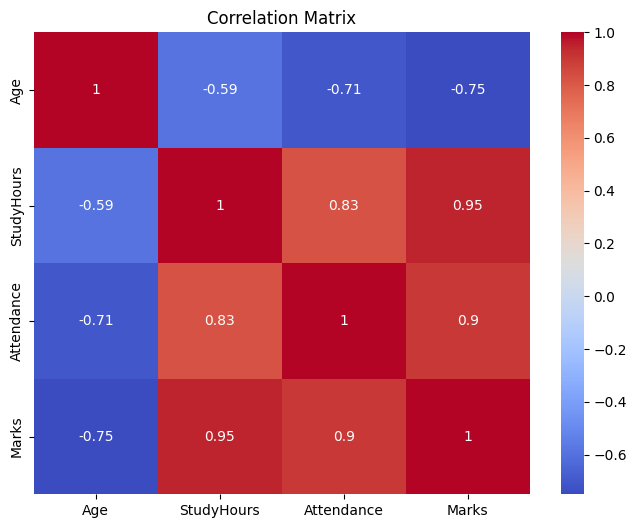

In [41]:
# Correlation

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

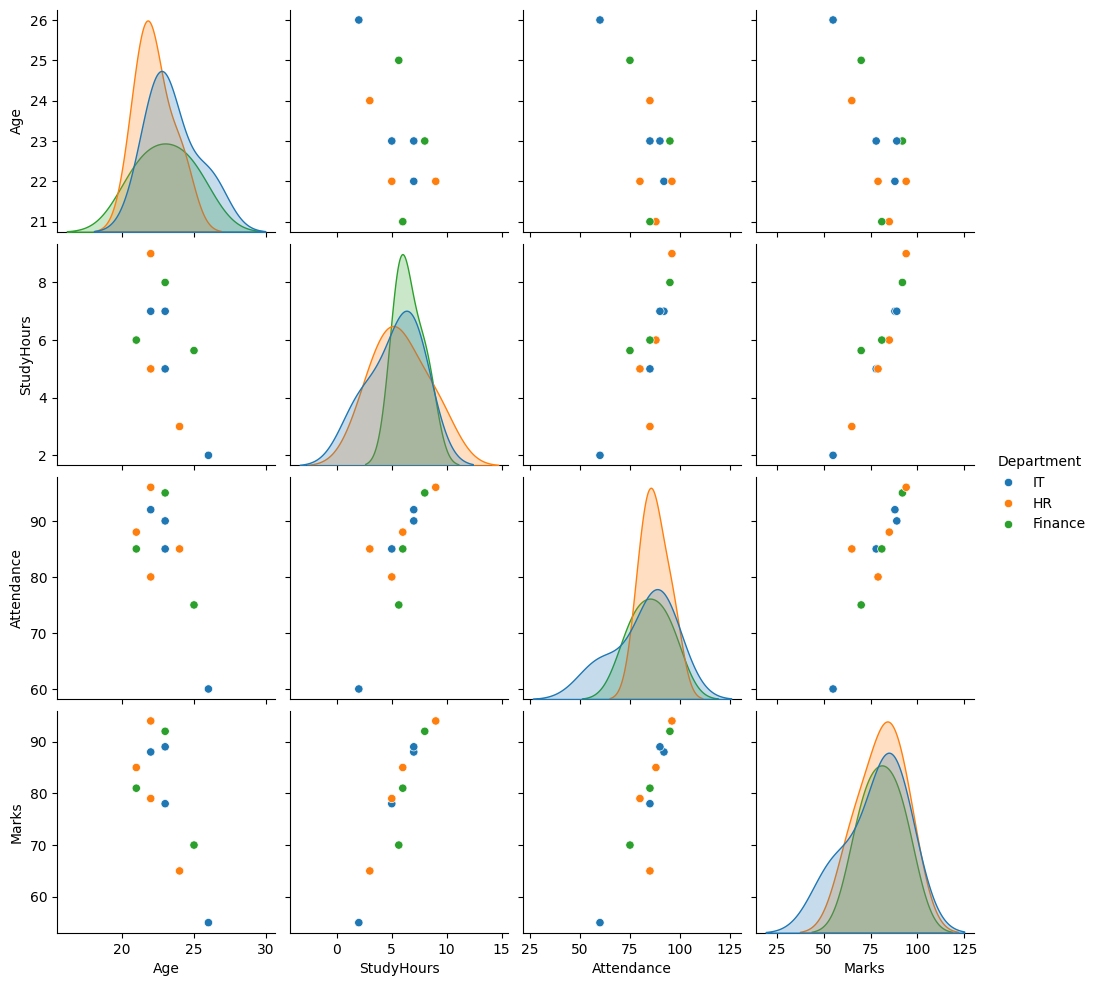

In [42]:
# Pair Plot
sns.pairplot(df, hue='Department')
plt.show()

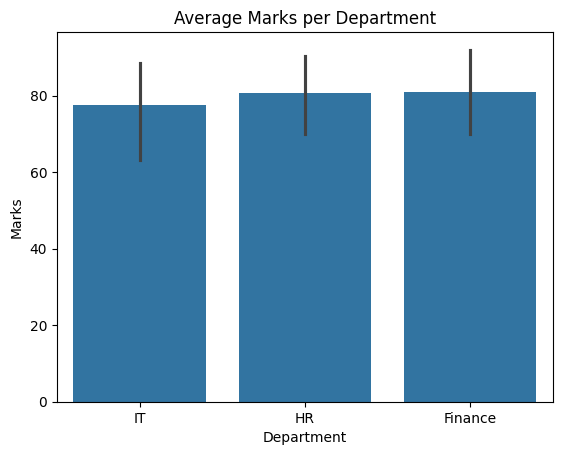

In [45]:
# GroupBy Analysis
df.groupby("Department")["Marks"].mean()

sns.barplot(x='Department', y='Marks', data=df)
plt.title("Average Marks per Department")
plt.show()

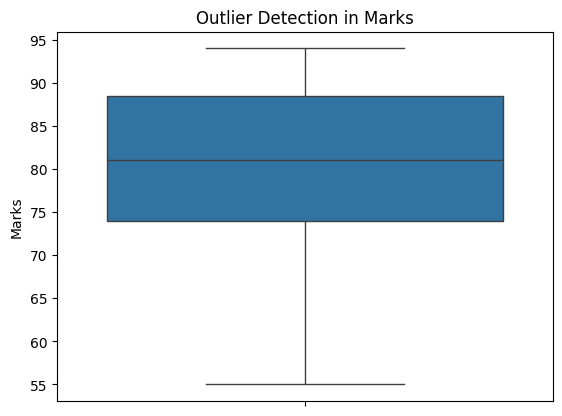

In [46]:
# Outlier Detection 
sns.boxplot(y=df['Marks'])
plt.title("Outlier Detection in Marks")
plt.show()

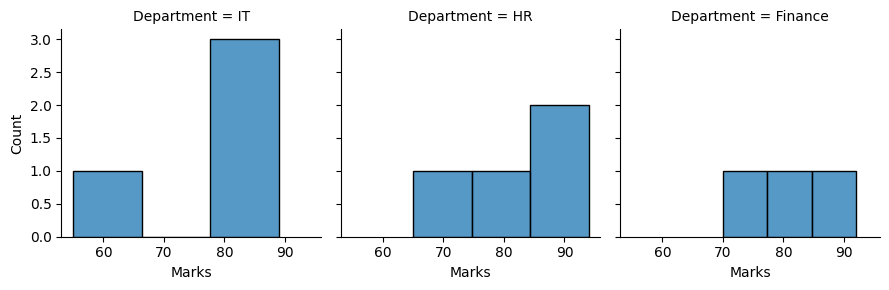

In [ ]:
# FaceGrid (Distribution per category)
g = sns.FacetGrid(df, col="Department")
g.map(sns.histplot, "Marks")
plt.show()

##  Conclusion

This project performed exploratory data analysis on student performance data using Pandas, NumPy, Matplotlib, and Seaborn. After handling missing values and removing outliers, various visualizations such as subplots, heatmaps, and pairplots were used to analyze distributions and relationships between features. 

The analysis showed that factors like study hours and attendance have a noticeable impact on marks, and performance varies across departments. Overall, the project demonstrates how data visualization can be used to extract meaningful insights from structured data.